# =================================================
# CUSTOMER CHURN PREDICTION - COMPLETE ML PIPELINE
# CLASSIFICATION PROBLEM
# =================================================

# Dataset:
# Telco Customer Churn Dataset
#
# CSV File:
# WA_Fn-UseC_-Telco-Customer-Churn.csv
#
# Goal:
# Predict whether customer will churn
#
# Target Column:
# Churn
# =================================================

# 1. IMPORT LIBRARIES

In [2]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")



# 2. DATA GATHERING

In [3]:
# =========================================================
# 2. DATA GATHERING
# =========================================================

# Read CSV file
df = pd.read_csv(
    "data/TelcoCustomerChurn/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print("=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)

print(df.head())


FIRST 5 ROWS
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        

# 3. BASIC DATA UNDERSTANDING

In [4]:
# =========================================================
# 3. BASIC DATA UNDERSTANDING
# =========================================================

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATA TYPES")
print(df.dtypes)

print("\nDATASET INFO")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe())




DATASET SHAPE
(7043, 21)

COLUMN NAMES
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

DATA TYPES
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn     

# 4. MISSING VALUES

In [5]:
# =========================================================
# 4. MISSING VALUES
# =========================================================

print("\nMISSING VALUES")

print(df.isnull().sum())




MISSING VALUES
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# 5. CHECK DUPLICATES

In [6]:
# =========================================================
# 5. CHECK DUPLICATES
# =========================================================

print("\nDUPLICATE RECORDS")

print(df.duplicated().sum())




DUPLICATE RECORDS
0


# 6. TARGET VARIABLE ANALYSIS

In [7]:
# =========================================================
# 6. TARGET VARIABLE ANALYSIS
# =========================================================

print("\nTARGET VARIABLE COUNTS")

print(df["Churn"].value_counts())




TARGET VARIABLE COUNTS
Churn
No     5174
Yes    1869
Name: count, dtype: int64


# 7. CLASS IMBALANCE VISUALIZATION

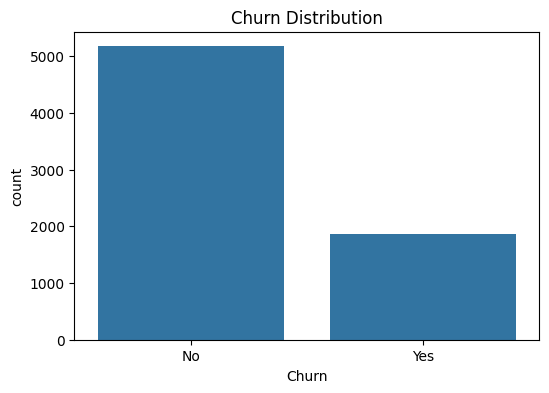

In [8]:
# =========================================================
# 7. CLASS IMBALANCE VISUALIZATION
# =========================================================

plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Churn Distribution")

plt.show()



# 8. CONVERT TOTALCHARGES TO NUMERIC

In [9]:
# =========================================================
# 8. CONVERT TOTALCHARGES TO NUMERIC
# =========================================================

# Some values may contain spaces
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("\nUPDATED DATA TYPES")

print(df.dtypes)



UPDATED DATA TYPES
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


# EDA - UNIVARIATE ANALYSIS

In [10]:
# =========================================================
# =========================================================
# EDA - UNIVARIATE ANALYSIS
# =========================================================
# =========================================================


# 9. HISTOGRAM

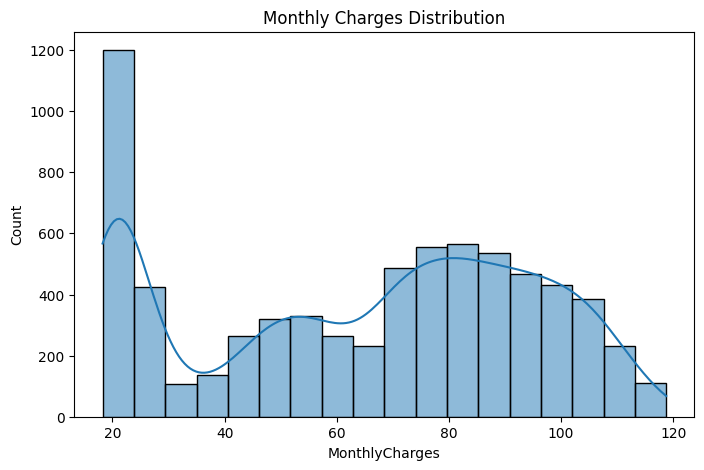

In [11]:
# =========================================================
# 9. HISTOGRAM
# =========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyCharges"],
    kde=True
)

plt.title("Monthly Charges Distribution")

plt.show()



# 10. BOXPLOT

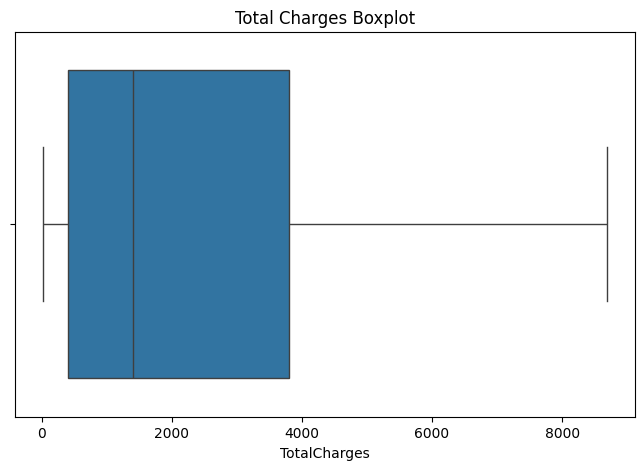

In [12]:
# =========================================================
# 10. BOXPLOT
# =========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["TotalCharges"]
)

plt.title("Total Charges Boxplot")

plt.show()



# 11. COUNTPLOT

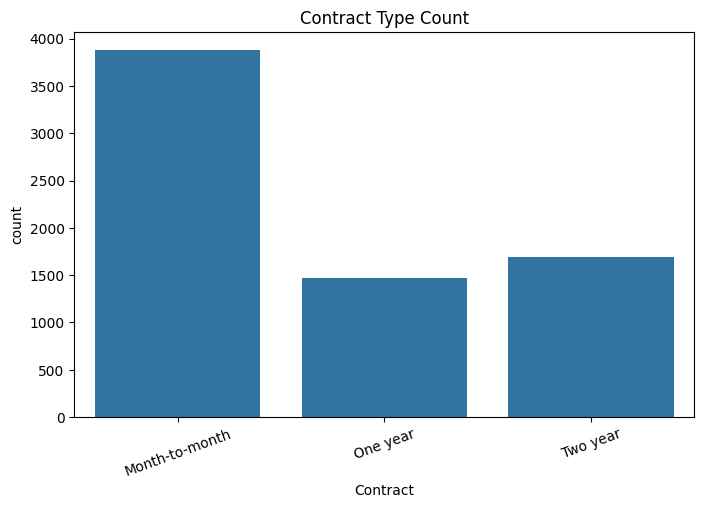

In [13]:
# =========================================================
# 11. COUNTPLOT
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    data=df
)

plt.title("Contract Type Count")

plt.xticks(rotation=20)

plt.show()



# 12. PIE CHART

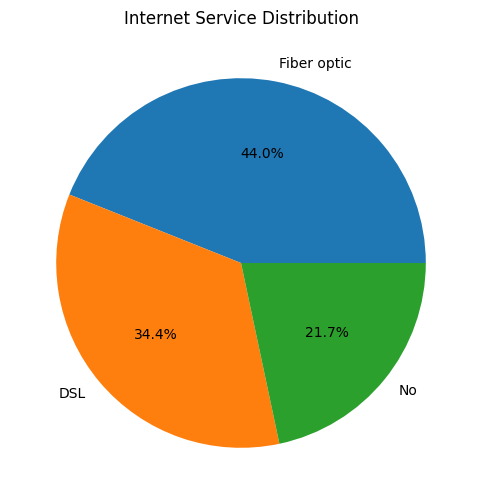

In [14]:
# =========================================================
# 12. PIE CHART
# =========================================================

internet_counts = df["InternetService"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    internet_counts,
    labels=internet_counts.index,
    autopct="%1.1f%%"
)

plt.title("Internet Service Distribution")

plt.show()



# MULTIVARIATE ANALYSIS

In [15]:
# =========================================================
# =========================================================
# MULTIVARIATE ANALYSIS
# =========================================================
# =========================================================


# 13. CHURN VS CONTRACT

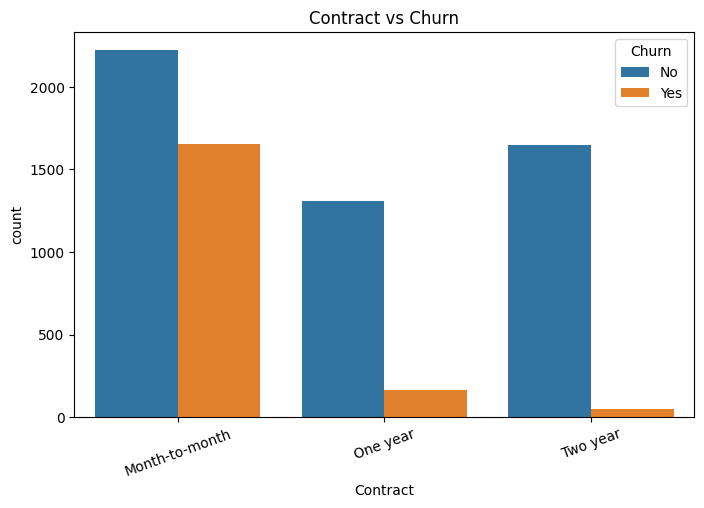

In [16]:
# =========================================================
# 13. CHURN VS CONTRACT
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract vs Churn")

plt.xticks(rotation=20)

plt.show()



# 14. CHURN VS PAYMENT METHOD

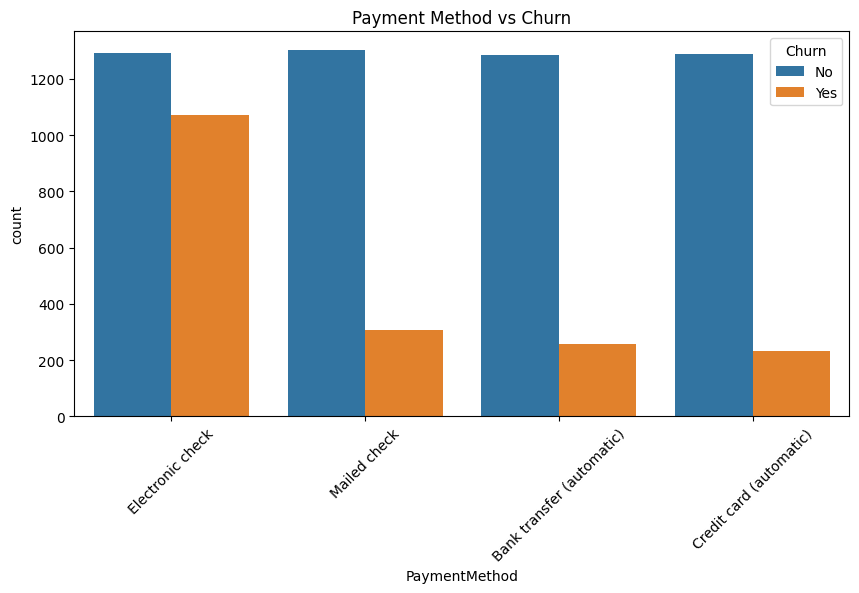

In [17]:
# =========================================================
# 14. CHURN VS PAYMENT METHOD
# =========================================================

plt.figure(figsize=(10,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.title("Payment Method vs Churn")

plt.xticks(rotation=45)

plt.show()



# 15. VIOLIN PLOT

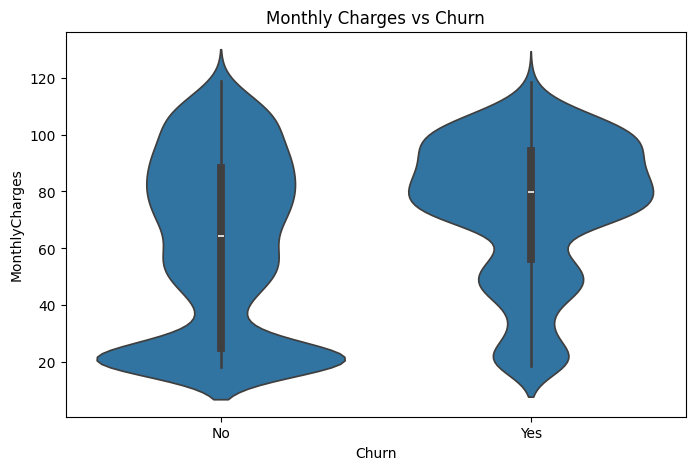

In [18]:
# =========================================================
# 15. VIOLIN PLOT
# =========================================================

plt.figure(figsize=(8,5))

sns.violinplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()



# 16. HEATMAP

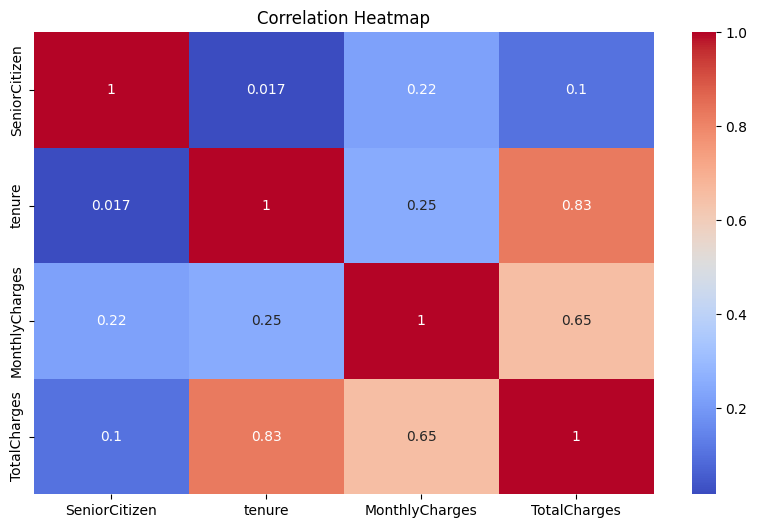

In [19]:
# =========================================================
# 16. HEATMAP
# =========================================================

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()



# FEATURE ENGINEERING

In [20]:
# =========================================================
# =========================================================
# FEATURE ENGINEERING
# =========================================================
# =========================================================


# 17. FEATURE CONSTRUCTION

In [21]:
# =========================================================
# 17. FEATURE CONSTRUCTION
# =========================================================

# Average monthly spend
df["AverageMonthlySpend"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

print("\nNEW FEATURE CREATED")

print(df["AverageMonthlySpend"].head())




NEW FEATURE CREATED
0    14.925000
1    53.985714
2    36.050000
3    40.016304
4    50.550000
Name: AverageMonthlySpend, dtype: float64


# 18. HANDLE MISSING VALUES

In [22]:
# =========================================================
# 18. HANDLE MISSING VALUES
# =========================================================

print("\nMISSING VALUES BEFORE")

print(df.isnull().sum())


# Fill TotalCharges missing values
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

print("\nMISSING VALUES AFTER")

print(df.isnull().sum())




MISSING VALUES BEFORE
customerID              0
gender                  0
SeniorCitizen           0
Partner                 0
Dependents              0
tenure                  0
PhoneService            0
MultipleLines           0
InternetService         0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMovies         0
Contract                0
PaperlessBilling        0
PaymentMethod           0
MonthlyCharges          0
TotalCharges           11
Churn                   0
AverageMonthlySpend    11
dtype: int64

MISSING VALUES AFTER
customerID              0
gender                  0
SeniorCitizen           0
Partner                 0
Dependents              0
tenure                  0
PhoneService            0
MultipleLines           0
InternetService         0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
Stream

# 19. DROP UNNECESSARY COLUMNS

In [23]:
# =========================================================
# 19. DROP UNNECESSARY COLUMNS
# =========================================================

# customerID not useful for prediction
df.drop(
    columns=["customerID"],
    inplace=True
)


# 20. ENCODE TARGET VARIABLE

In [24]:
# =========================================================
# 20. ENCODE TARGET VARIABLE
# =========================================================

# Yes -> 1
# No  -> 0

df["Churn"] = df["Churn"].map({

    "Yes": 1,
    "No": 0

})

print("\nTARGET ENCODED")

print(df["Churn"].head())




TARGET ENCODED
0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


# 21. FEATURE SELECTION

In [25]:
# =========================================================
# 21. FEATURE SELECTION
# =========================================================

X = df.drop("Churn", axis=1)

y = df["Churn"]



# 22. IDENTIFY FEATURE TYPES

In [26]:
# =========================================================
# 22. IDENTIFY FEATURE TYPES
# =========================================================

numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

print("\nNUMERICAL FEATURES")

print(numerical_features)

print("\nCATEGORICAL FEATURES")

print(categorical_features)



NUMERICAL FEATURES
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlySpend']

CATEGORICAL FEATURES
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


# 23. COLUMN TRANSFORMER

In [28]:
# =========================================================
# 23. COLUMN TRANSFORMER
# =========================================================

numeric_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "scaler",
            StandardScaler()
        )

    ]
)

categorical_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )

    ]
)

preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            numeric_transformer,
            numerical_features
        ),

        (
            "cat",
            categorical_transformer,
            categorical_features
        )

    ]
)


# 24. TRAIN TEST SPLIT

In [29]:
# =========================================================
# 24. TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print("\nTRAIN SHAPE")

print(X_train.shape)

print("\nTEST SHAPE")

print(X_test.shape)



TRAIN SHAPE
(5634, 20)

TEST SHAPE
(1409, 20)


# MODEL BUILDING

In [30]:
# =========================================================
# =========================================================
# MODEL BUILDING
# =========================================================
# =========================================================


# 25. CREATE PIPELINE

In [31]:
# =========================================================
# 25. CREATE PIPELINE
# =========================================================

model = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            LogisticRegression()
        )

    ]
)


# 26. TRAIN MODEL

In [32]:
# =========================================================
# 26. TRAIN MODEL
# =========================================================

model.fit(
    X_train,
    y_train
)

print("\nMODEL TRAINED")




MODEL TRAINED


# 27. PREDICTIONS

In [33]:
# =========================================================
# 27. PREDICTIONS
# =========================================================

y_pred = model.predict(X_test)

print("\nPREDICTIONS")

print(y_pred[:10])



PREDICTIONS
[0 1 0 0 0 1 0 0 0 0]


# 28. PREDICTION PROBABILITIES

In [34]:
# =========================================================
# 28. PREDICTION PROBABILITIES
# =========================================================

# Probability of churn
y_prob = model.predict_proba(X_test)[:, 1]

print("\nPREDICTION PROBABILITIES")

print(y_prob[:10])



PREDICTION PROBABILITIES
[0.04605258 0.56878714 0.06012164 0.3243422  0.02832798 0.59988255
 0.44939341 0.14557171 0.00369881 0.32780473]


# MODEL EVALUATION

In [35]:
# =========================================================
# =========================================================
# MODEL EVALUATION
# =========================================================
# =========================================================


# 29. ACCURACY

In [37]:
# =========================================================
# 29. ACCURACY
# =========================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nACCURACY")

print(accuracy)



ACCURACY
0.8097941802696949


# 30. CONFUSION MATRIX


CONFUSION MATRIX
[[941  94]
 [174 200]]


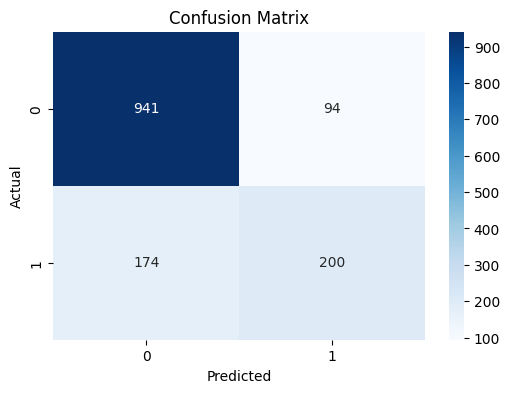

In [38]:
# =========================================================
# 30. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nCONFUSION MATRIX")

print(cm)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


# 31. CLASSIFICATION REPORT

In [39]:
# =========================================================
# 31. CLASSIFICATION REPORT
# =========================================================

print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        y_pred
    )
)



CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1035
           1       0.68      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



# 32. ROC CURVE

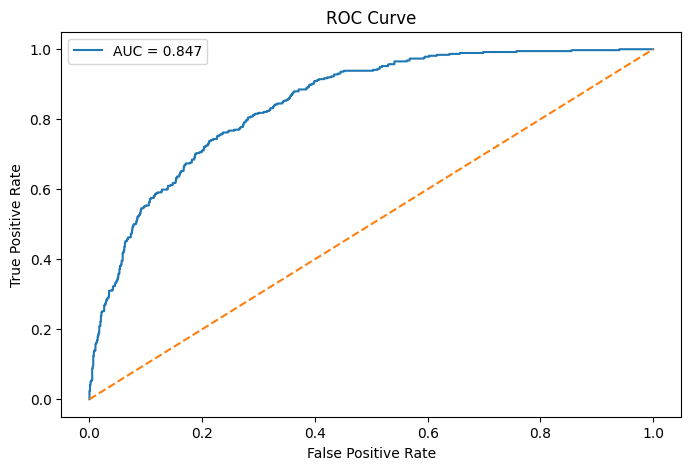

In [40]:
# =========================================================
# 32. ROC CURVE
# =========================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()



# 33. FEATURE IMPORTANCE

In [41]:
# =========================================================
# 33. FEATURE IMPORTANCE
# =========================================================

feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = model.named_steps[
    "classifier"
].coef_[0]

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Coefficient": coefficients

})

importance_df["AbsCoefficient"] = np.abs(
    importance_df["Coefficient"]
)

importance_df = importance_df.sort_values(
    by="AbsCoefficient",
    ascending=False
)

print("\nTOP IMPORTANT FEATURES")

print(
    importance_df[
        ["Feature", "Coefficient"]
    ].head(10)
)



TOP IMPORTANT FEATURES
                                      Feature  Coefficient
4                    num__AverageMonthlySpend    -1.113664
1                                 num__tenure    -0.940681
39                     cat__Contract_Two year    -0.900059
17           cat__InternetService_Fiber optic     0.820723
16                   cat__InternetService_DSL    -0.778845
37               cat__Contract_Month-to-month     0.660947
3                           num__TotalCharges     0.480866
20    cat__OnlineSecurity_No internet service    -0.368895
29       cat__TechSupport_No internet service    -0.368895
26  cat__DeviceProtection_No internet service    -0.368895


# 34. FEATURE IMPORTANCE GRAPH

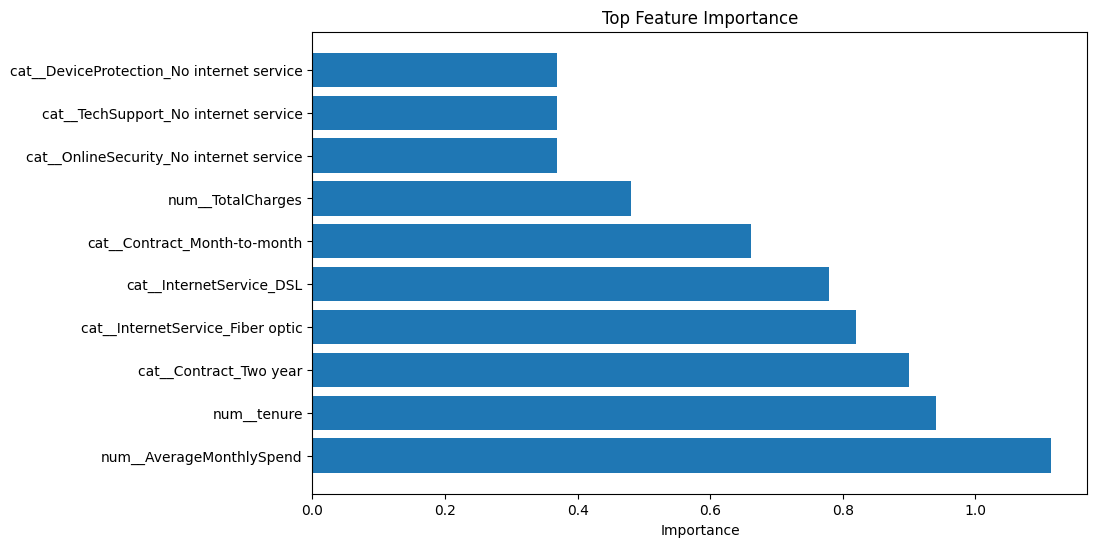

In [42]:
# =========================================================
# 34. FEATURE IMPORTANCE GRAPH
# =========================================================

top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["AbsCoefficient"]
)

plt.title("Top Feature Importance")

plt.xlabel("Importance")

plt.show()


# 35. THRESHOLD TUNING EXAMPLE

In [43]:
# =========================================================
# 35. THRESHOLD TUNING EXAMPLE
# =========================================================

# Default threshold = 0.5
custom_pred = (y_prob >= 0.3).astype(int)

print("\nCUSTOM THRESHOLD PREDICTION")

print(custom_pred[:10])



CUSTOM THRESHOLD PREDICTION
[0 1 0 1 0 1 1 0 0 1]


# 36. SAMPLE PREDICTION

In [44]:
# =========================================================
# 36. SAMPLE PREDICTION
# =========================================================

sample_customer = pd.DataFrame({

    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["Yes"],
    "Dependents": ["No"],
    "tenure": [12],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["Yes"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [89.5],
    "TotalCharges": [1100],
    "AverageMonthlySpend": [84]

})

sample_prediction = model.predict(
    sample_customer
)

sample_probability = model.predict_proba(
    sample_customer
)[:,1]

print("\nSAMPLE PREDICTION")

if sample_prediction[0] == 1:

    print("Customer Will Churn")

else:

    print("Customer Will Not Churn")

print("\nCHURN PROBABILITY")

print(sample_probability[0])




SAMPLE PREDICTION
Customer Will Churn

CHURN PROBABILITY
0.6686530971502517


# =======================================
# IMPORTANT CONCEPTS COVERED
# =======================================

"""
IMPORTANT NEW CONCEPTS:

1. Class Imbalance
2. ROC Curve
3. AUC Score
4. Probability Prediction
5. Threshold Tuning
6. Feature Importance
7. Business Classification
8. Churn Prediction
9. Stratified Split
10. Classification Metrics

IMPORTANT BUSINESS ML CONCEPTS:

Precision:
How many predicted positives are correct

Recall:
How many actual positives are detected

ROC Curve:
Classification performance at different thresholds

AUC:
Overall classification quality

Threshold Tuning:
Changing classification cutoff

Probability Prediction:
Predicting likelihood instead of just class
"""